In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Food_Waste_Prediction_Dataset (1).xlsx to Food_Waste_Prediction_Dataset (1).xlsx


In [4]:
import pandas as pd

df = pd.read_excel("/content/Food_Waste_Prediction_Dataset (1).xlsx")

print(df.head())

  Restaurant_ID Restaurant_Name        City       Cuisine Food_Item  \
0          R001    Spice Garden     Chennai  South Indian    Pongal   
1          R005      Green Bowl      Mumbai  South Indian      Dosa   
2          R002     Urban Bites   Bengaluru       Italian     Pasta   
3          R004        Food Hub  Coimbatore  South Indian     Meals   
4          R003     Ocean Treat   Hyderabad  South Indian      Dosa   

         Date  Prepared_Quantity  Sold_Quantity  Remaining_Quantity  \
0  2025-05-06                107            102                   5   
1  2025-11-29                229            198                  31   
2  2025-05-23                 89             89                   0   
3  2025-02-10                191            175                  16   
4  2025-02-21                147            113                  34   

   Temperature_C Weather Weekend Holiday  Discount_Percent  Customers  \
0             25  Cloudy      No      No                20        121   


In [5]:
print(df.shape)
df.info()

(1000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Restaurant_ID       1000 non-null   object 
 1   Restaurant_Name     1000 non-null   object 
 2   City                1000 non-null   object 
 3   Cuisine             1000 non-null   object 
 4   Food_Item           1000 non-null   object 
 5   Date                1000 non-null   object 
 6   Prepared_Quantity   1000 non-null   int64  
 7   Sold_Quantity       1000 non-null   int64  
 8   Remaining_Quantity  1000 non-null   int64  
 9   Temperature_C       1000 non-null   int64  
 10  Weather             1000 non-null   object 
 11  Weekend             1000 non-null   object 
 12  Holiday             1000 non-null   object 
 13  Discount_Percent    1000 non-null   int64  
 14  Customers           1000 non-null   int64  
 15  Waste_Amount_kg     1000 non-null   float64
d

In [6]:
print("Missing Values\n")
print(df.isnull().sum())

Missing Values

Restaurant_ID         0
Restaurant_Name       0
City                  0
Cuisine               0
Food_Item             0
Date                  0
Prepared_Quantity     0
Sold_Quantity         0
Remaining_Quantity    0
Temperature_C         0
Weather               0
Weekend               0
Holiday               0
Discount_Percent      0
Customers             0
Waste_Amount_kg       0
dtype: int64


In [7]:

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

print(df.isnull().sum())

Restaurant_ID         0
Restaurant_Name       0
City                  0
Cuisine               0
Food_Item             0
Date                  0
Prepared_Quantity     0
Sold_Quantity         0
Remaining_Quantity    0
Temperature_C         0
Weather               0
Weekend               0
Holiday               0
Discount_Percent      0
Customers             0
Waste_Amount_kg       0
dtype: int64


In [8]:
print("Duplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After Removal :", df.shape)

Duplicate Rows : 0
After Removal : (1000, 16)


In [9]:
Q1 = df["Waste_Amount_kg"].quantile(0.25)
Q3 = df["Waste_Amount_kg"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Waste_Amount_kg"] < lower) |
    (df["Waste_Amount_kg"] > upper)
]

print(outliers.head())
print("Number of outliers:", len(outliers))

    Restaurant_ID Restaurant_Name        City       Cuisine   Food_Item  \
145          R002     Urban Bites   Bengaluru       Chinese     Noodles   
278          R005      Green Bowl      Mumbai       Chinese  Manchurian   
316          R004        Food Hub  Coimbatore  South Indian       Meals   
590          R003     Ocean Treat   Hyderabad  North Indian     Biryani   
693          R003     Ocean Treat   Hyderabad       Italian       Pasta   

           Date  Prepared_Quantity  Sold_Quantity  Remaining_Quantity  \
145  2025-07-16                293            201                  92   
278  2025-04-30                299            198                 101   
316  2025-01-28                271            171                 100   
590  2025-01-03                299            201                  98   
693  2025-02-12                266            168                  98   

     Temperature_C Weather Weekend Holiday  Discount_Percent  Customers  \
145             26  Cloudy      No 

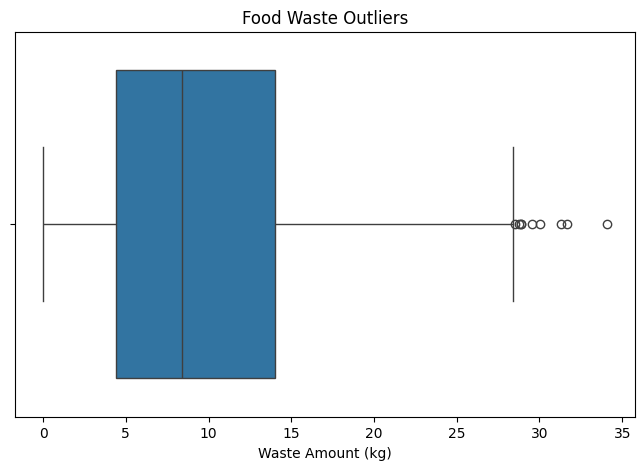

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Waste_Amount_kg"])

plt.title("Food Waste Outliers")
plt.xlabel("Waste Amount (kg)")

plt.show()

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["Waste_Amount_kg"]] = scaler.fit_transform(
    df[["Waste_Amount_kg"]]
)

print(df[["Waste_Amount_kg"]].head())

   Waste_Amount_kg
0         0.032002
1         0.164709
2         0.000000
3         0.137405
4         0.289783


In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Weather"] = encoder.fit_transform(df["Weather"])

print(df[["Weather"]].head())

   Weather
0        0
1        2
2        2
3        0
4        2


In [13]:
encoder = LabelEncoder()

categorical_columns = [
    "City",
    "Cuisine",
    "Food_Item",
    "Weather",
    "Weekend",
    "Holiday"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print(df[categorical_columns].head())

   City  Cuisine  Food_Item  Weather  Weekend  Holiday
0     1        3         11        0        0        0
1     4        3          1        2        1        0
2     0        1          9        2        0        0
3     2        3          5        0        0        0
4     3        3          1        2        0        0


In [14]:
cuisine = pd.get_dummies(df["Cuisine"], prefix="Cuisine")

df = pd.concat([df, cuisine], axis=1)

print(cuisine.head())

   Cuisine_0  Cuisine_1  Cuisine_2  Cuisine_3
0      False      False      False       True
1      False      False      False       True
2      False       True      False      False
3      False      False      False       True
4      False      False      False       True


In [15]:
df.to_csv("/content/Food_Waste_Prediction_Dataset_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
